## Architecture
In this architecuter, first feature are extracted through the Frozen EfficieneNetB1 and then additional 4 FiLMed block added where each block consist of convolutional layer, Batch Norm layer, activation (Relu), and inside each block FiLM layer is applied on feature maps/channels. rather it is additional layer on the top of extracted features from the finetuned backbone. 

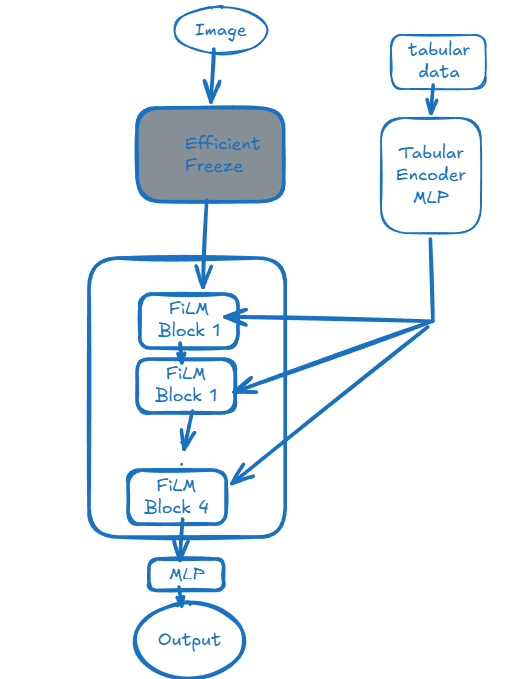

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
sys.path.insert(0, os.path.abspath("../../../.."))

In [3]:
# Cell 1: imports & setup
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gc

gc.enable()

import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error

from src.config import EXP_CONFIGS
from src.utils import set_seed, save_config




main_folder = "../../../.."
data_csv = os.path.join(main_folder, "data", "train.csv")
img_folder = os.path.join(main_folder, "data", "train")
out_dir = os.path.join(main_folder, "outputs","extra","exp12_film_effB1_strongAug384_BS12_identity" "exp12_film_fusion_EfficientNetB1_ExternalModulation_FreezeBackbone_identity_init")   # 

df = pd.read_csv(data_csv)
cfg = EXP_CONFIGS["exp12_film"]   # define in config
cfg["name"] = "exp12_film_fusion_ExternalModulation_FreezeBackbone_EffB1_identity_init"
cfg["img_size"] = 384
cfg["aug"] = "strong"
cfg["batch_size"] = 12

TARGET = "Pawpularity"
tab_cols = [c for c in df.columns if c not in ["Id", TARGET]]

os.makedirs(out_dir, exist_ok=True)
save_config(cfg, out_dir)
set_seed(cfg["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from src.train import run_single_fold

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
oof_pred = np.zeros(len(df))
oof_true = df[TARGET].values
fold_index = np.full(len(df), -1, dtype=int)
fold_rmse = []

start_all = time.time()
for fold, (tr_idx, val_idx) in enumerate(kf.split(df), start=1):
    print(f"\n=== {cfg['name']}: Fold {fold} ===")
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)

    best_rmse, val_preds, val_targets, val_ids = run_single_fold(
    fold=fold,
    train_df=train_df,
    val_df=val_df,
    img_folder=img_folder,
    cfg=cfg,
    out_dir=out_dir,
    device=device,
    mode="film_stack_effb1",   # <--- use FiLMExternalModulation    branch
    tab_cols=tab_cols,
    workers=16,
    pin_memory=True,
    persistent_workers=True,
    freeze_backbone=True,
    identity_init=True
)

    oof_pred[val_idx] = val_preds
    fold_index[val_idx] = fold
    fold_rmse.append(best_rmse)
    print(f"Fold {fold} best RMSE: {best_rmse:.4f}")

all_sec = time.time() - start_all
print(f"\nTotal training time: {int(all_sec//60)}m {int(all_sec%60)}s")
# final metrics + OOF with fold column
oof_rmse = root_mean_squared_error(oof_true, oof_pred)
fold_rmse = np.array(fold_rmse)
print(f"\nOOF RMSE: {oof_rmse:.4f}")
print(f"Fold RMSEs: {fold_rmse.tolist()}  Mean={fold_rmse.mean():.4f}  Std={fold_rmse.std():.4f}")

oof_df = pd.DataFrame({
    "Id": df["Id"],
    "fold": fold_index,     
    "ytrue": oof_true,
    "oof_pred": oof_pred,
})
oof_df["abs_err"] = (oof_df["ytrue"] - oof_df["oof_pred"]).abs()
oof_df.to_csv(os.path.join(out_dir, "oof_detail.csv"), index=False)
oof_df.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(out_dir, "top50_errors.csv"), index=False
)

np.save(os.path.join(out_dir, "oof_pred.npy"), oof_pred)
np.save(os.path.join(out_dir, "fold_rmse.npy"), fold_rmse)
with open(os.path.join(out_dir, "metrics.txt"), "w") as f:
    f.write(f"OOF_RMSE: {oof_rmse:.4f}\n")
    f.write(f"Fold_RMSE: {fold_rmse.tolist()}\nMean: {fold_rmse.mean():.4f}\nStd: {fold_rmse.std():.4f}\n")



=== exp12_film_fusion_ExternalModulation_FreezeBackbone_EffB1_identity_init: Fold 1 ===
Epoch 1/10 | Fold 1 | Train[MSE]: RMSE=24.2933 | ValRMSE: 20.2539
Epoch 2/10 | Fold 1 | Train[MSE]: RMSE=19.7386 | ValRMSE: 19.7686
Epoch 3/10 | Fold 1 | Train[MSE]: RMSE=19.6396 | ValRMSE: 19.6888
Epoch 4/10 | Fold 1 | Train[MSE]: RMSE=19.4270 | ValRMSE: 19.9475
Epoch 5/10 | Fold 1 | Train[MSE]: RMSE=19.3813 | ValRMSE: 19.7385
Epoch 6/10 | Fold 1 | Train[MSE]: RMSE=19.2624 | ValRMSE: 19.6334
Epoch 7/10 | Fold 1 | Train[MSE]: RMSE=19.1754 | ValRMSE: 19.7114
Epoch 8/10 | Fold 1 | Train[MSE]: RMSE=19.2416 | ValRMSE: 19.6501
Epoch 9/10 | Fold 1 | Train[MSE]: RMSE=19.1419 | ValRMSE: 19.6094
Epoch 10/10 | Fold 1 | Train[MSE]: RMSE=19.1140 | ValRMSE: 19.5963
Fold 1 best RMSE: 19.5963

=== exp12_film_fusion_ExternalModulation_FreezeBackbone_EffB1_identity_init: Fold 2 ===
Epoch 1/10 | Fold 2 | Train[MSE]: RMSE=23.8543 | ValRMSE: 20.5171
Epoch 2/10 | Fold 2 | Train[MSE]: RMSE=20.4588 | ValRMSE: 20.3325
Epo

In [5]:
#oof rmse = 19.8284
import pandas
df = pd.read_csv(out_dir+"/oof_detail.csv")
fold_rmse = []

for fold in range(1, 6):
    sub = df[df.fold == fold]
    rmse = ((sub.ytrue - sub.oof_pred)**2).mean() ** 0.5
    fold_rmse.append(rmse)
    print(f"Fold {fold} OOF RMSE: {rmse:.4f} (n={len(sub)})")

Fold 1 OOF RMSE: 19.5963 (n=1983)
Fold 2 OOF RMSE: 19.6410 (n=1983)
Fold 3 OOF RMSE: 18.7253 (n=1982)
Fold 4 OOF RMSE: 19.5205 (n=1982)
Fold 5 OOF RMSE: 19.8826 (n=1982)


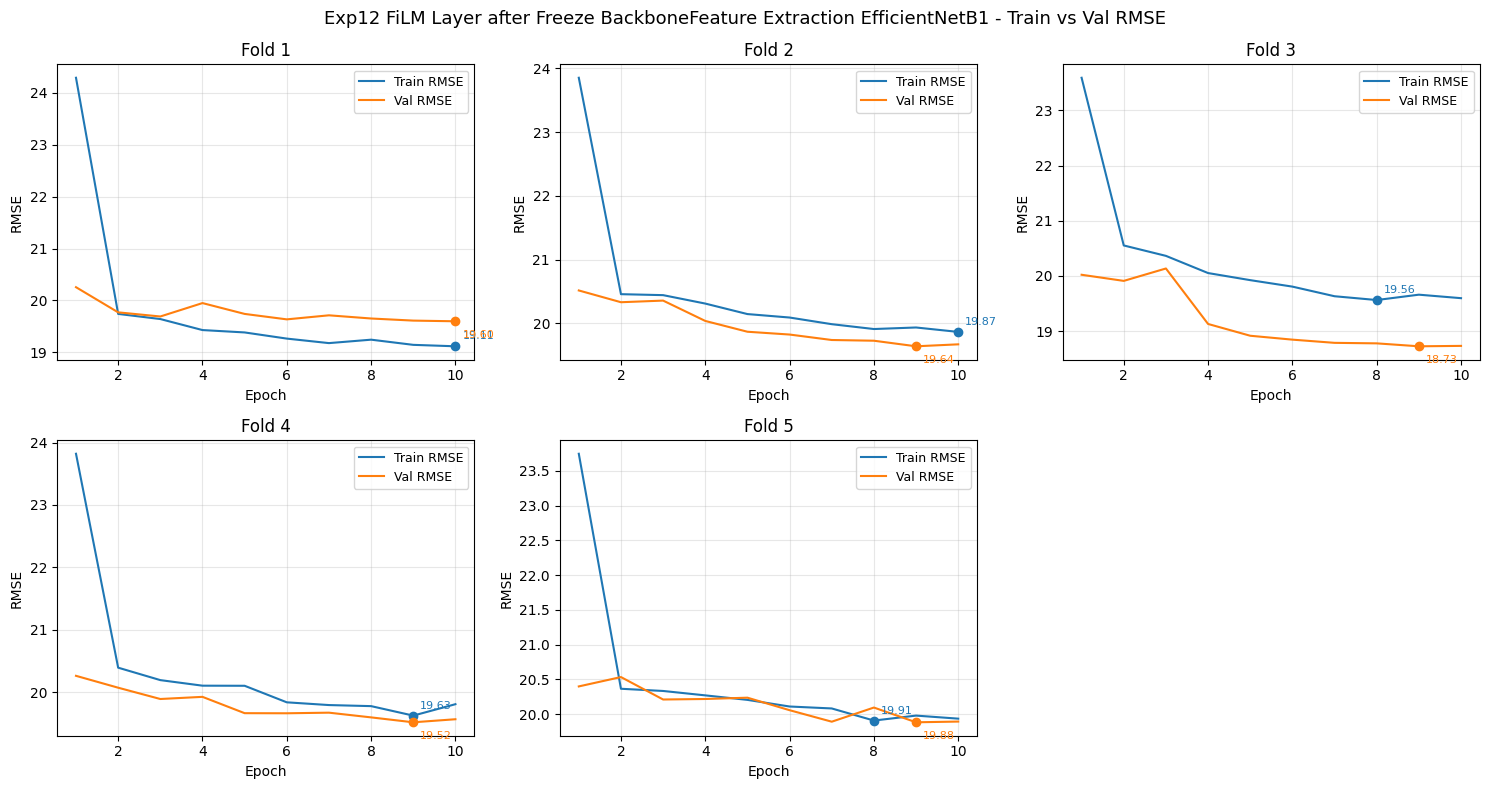

In [6]:
from src.plot import plot_train_val_history
plot_train_val_history(out_dir, folds=[1,2,3,4,5], title_prefix="Exp12 FiLM Layer after Freeze BackboneFeature Extraction EfficientNetB1")

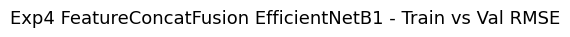

In [7]:
from src.plot import plot_train_val_history
out_dir1 = os.path.join("../..", "outputs", "exp4")
plot_train_val_history(out_dir1, folds=[1,2,3,4,5], title_prefix="Exp4 FeatureConcatFusion EfficientNetB1")

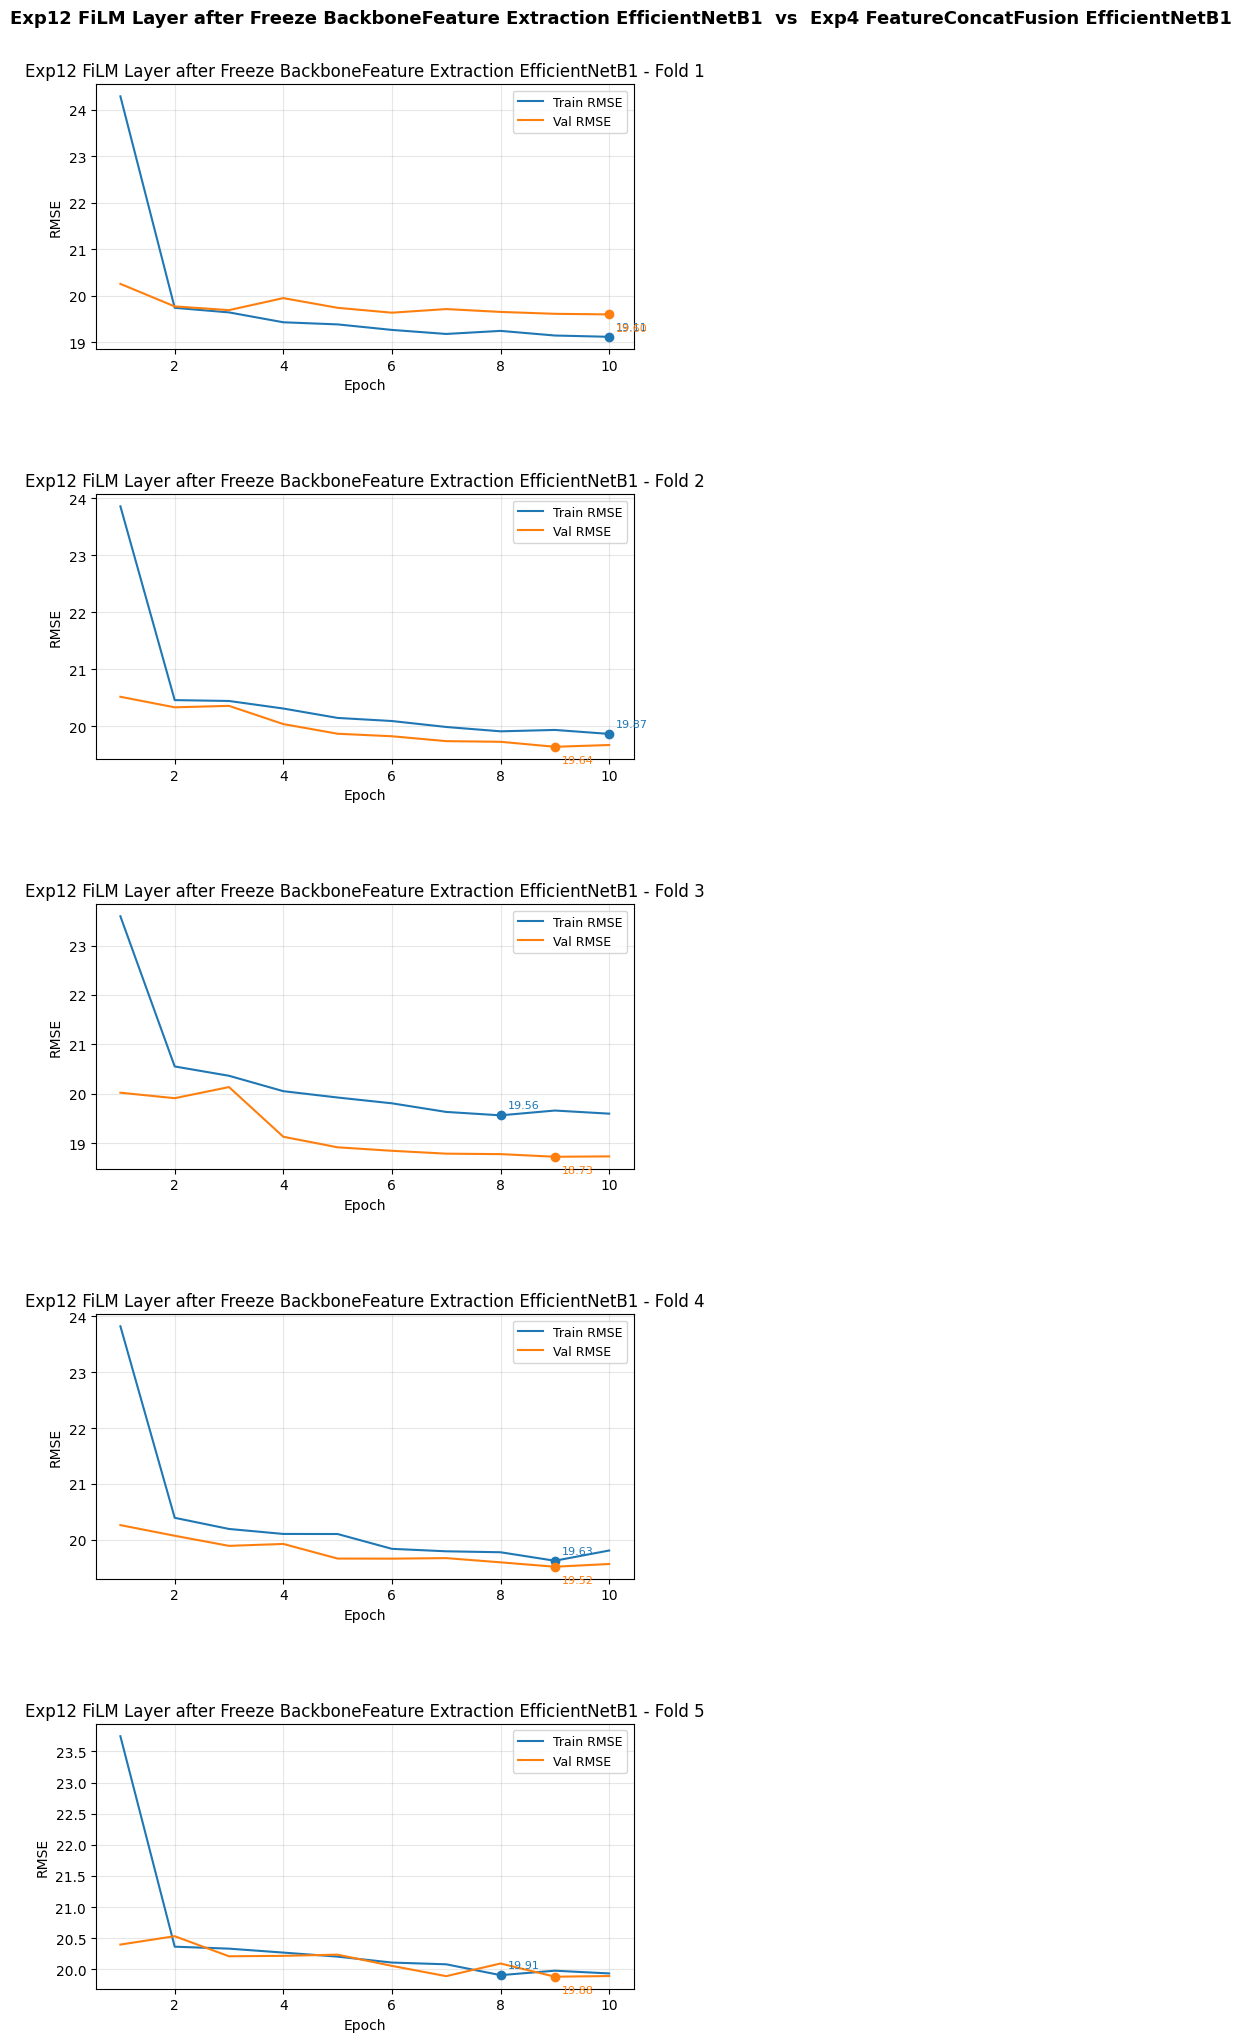

In [8]:
from src.plot import plot_compare_two_experiments
plot_compare_two_experiments(out_dir, out_dir1,folds=[1,2,3,4,5], label_a="Exp12 FiLM Layer after Freeze BackboneFeature Extraction EfficientNetB1", label_b="Exp4 FeatureConcatFusion EfficientNetB1")

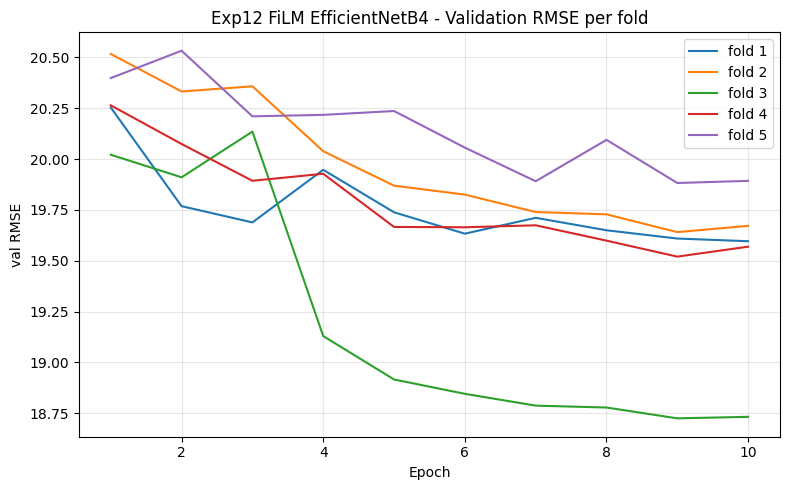

In [9]:
from src.plot import plot_all_folds_history
plot_all_folds_history(out_dir, folds=[1,2,3,4,5], title_prefix="Exp12 FiLM EfficientNetB4")

In [10]:
#  Inspect worst error rows

errors_path = os.path.join(out_dir, "top50_errors.csv")
err_df = pd.read_csv(errors_path)
err_df.head()

,Id,fold,ytrue,oof_pred,abs_err
0,d00e5d29d4ec09de1e0e0ebec41b2d03,1,5,80.610184,75.610184
1,054cef9194f1a4513dc0965893b589bf,3,2,75.027481,73.027481
2,ee7d8deda7e7e353f9d7866fe8d5ef04,5,100,29.070856,70.929144
3,2e96d3ea1d43e9006a19dcb87c3e686b,1,23,93.465012,70.465012
4,6dcb7396e06ee6a538522d2f67f017db,5,100,29.680580,70.319420


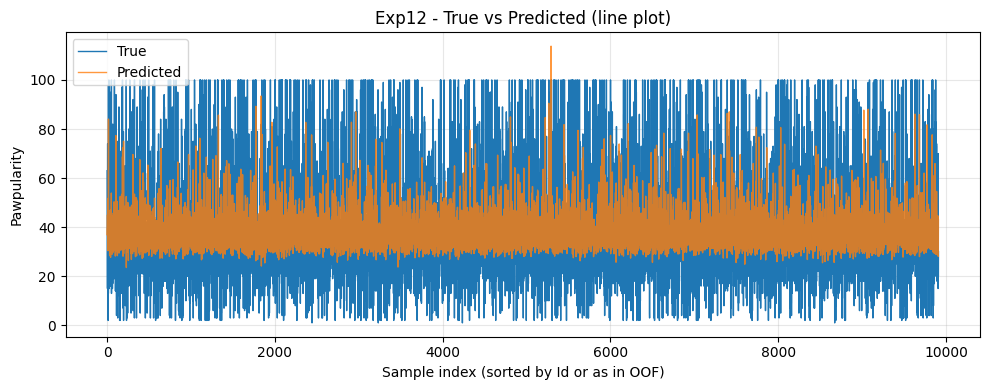

In [11]:
import os
import pandas as pd
from src.plot import (
   plot_oof_true_pred_lines,
    show_images_grid,
)

# Load OOF detail and top-errors
oof_df = pd.read_csv(os.path.join(out_dir, "oof_detail.csv"))
err_df = pd.read_csv(os.path.join(out_dir, "top50_errors.csv"))

# Plot
plot_oof_true_pred_lines(oof_df, title_prefix="Exp12")





In [12]:
from src.plot import compare_oof_by_bins
bins = [0, 20, 40, 60, 80, 100]

df_bins, rmse3_all, rmse5_all, gap = compare_oof_by_bins(
    oof_path_a=os.path.join(out_dir, "oof_detail.csv"),
    oof_path_b=os.path.join(out_dir1, "oof_detail.csv"),
    bins=bins,
    label_a="Exp12_FiLM_Eff_B1 Frozen image backbone and  External layer FiLM Fusion",
    label_b="Exp4_FeatureConcat EffB1 Fusion",
    title_prefix="EfficientNet",
)

FileNotFoundError: [Errno 2] No such file or directory: '../../outputs/exp4/oof_detail.csv'

In [ ]:
df_bins.head()

,bin,count,Exp12_FiLM_Eff_B1 Frozen image backbone and External layer FiLM Fusion_rmse,Exp4_FeatureConcat EffB1 Fusion_rmse,rmse_diff,winner
0,"(0, 20]",1417,25.828452,23.561754,-2.266699,Exp4_FeatureConcat EffB1 Fusion_better
1,"(20, 40]",5119,10.242041,11.605182,1.363140,Exp12_FiLM_Eff_B1 Frozen image backbone and E...
2,"(40, 60]",2088,11.837067,16.538259,4.701192,Exp12_FiLM_Eff_B1 Frozen image backbone and E...
3,"(60, 80]",727,29.499361,30.127592,0.628231,Exp12_FiLM_Eff_B1 Frozen image backbone and E...
4,"(80, 100]",561,53.404756,46.623998,-6.780758,Exp4_FeatureConcat EffB1 Fusion_better


: 

: 

: 

: 